# Hotel Revenue Forecasting Pipeline

**Enjoy Costa Rica — Revenue Analytics**

Pipeline completo de pronóstico de series temporales para la predicción de ingresos hoteleros.

## Estructura del Notebook

| Sección | Descripción |
|---------|-------------|
| 0 | Setup & Configuración |
| 1 | Carga de Datos |
| 2 | Análisis Exploratorio (EDA) |
| 3 | Preprocesamiento & Feature Engineering |
| 4 | Modelos Estadísticos (Prophet, SARIMA, ETS) |
| 5 | Modelos de ML (LightGBM, XGBoost, CatBoost) |
| 6 | Modelos de DL (TimesFM, PatchTST) |
| 7 | Comparación Final & Evaluación |
| 8 | Pronóstico Futuro |
| 9 | Conclusiones & Recomendaciones |

---
## Section 0: Setup & Imports

In [1]:
import sys
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(name)s - %(levelname)s - %(message)s')

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Add src to path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

# Load config
CONFIG_PATH = PROJECT_ROOT / 'config.yaml'
with open(CONFIG_PATH) as f:
    CONFIG = yaml.safe_load(f)

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version}")
print(f"NumPy: {np.__version__}, Pandas: {pd.__version__}")
print(f"Config loaded: {list(CONFIG.keys())}")

Project root: c:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec
Python: 3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]
NumPy: 2.3.5, Pandas: 2.3.3
Config loaded: ['random_seed', 'log_level', 'data', 'preprocessing', 'models', 'evaluation', 'forecasting', 'visualization']


In [2]:
# Import forecasting modules
from src.forecasting.data import DataLoader
from src.forecasting.eda import EDAAnalyzer, EDAVisualizer
from src.forecasting.preprocessing import PreprocessingPipeline
from src.forecasting.models.statistical import ProphetForecaster, SARIMAXForecaster, ETSForecaster
from src.forecasting.models.ml import LightGBMForecaster, XGBoostForecaster, CatBoostForecaster
from src.forecasting.evaluation import Evaluator, EvaluationVisualizer
from src.forecasting.forecasting import FutureForecaster

print("All modules imported successfully!")

All modules imported successfully!


---
## Section 1: Data Loading

In [3]:
# Load data — using sample data for offline development
# To use SQL: DataLoader(db_config={"host": "...", "database": "..."})
loader = DataLoader(csv_path=PROJECT_ROOT / 'data' / 'hotel_data.csv')

try:
    df = loader.load()
    print(f"Loaded {len(df)} rows from source.")
except FileNotFoundError:
    print("CSV not found. Generating synthetic sample data for development...")
    df = loader.load_sample(n_hotels=5, n_days=365*3, seed=SEED)
    # Save for future use
    (PROJECT_ROOT / 'data').mkdir(exist_ok=True)
    df.to_csv(PROJECT_ROOT / 'data' / 'hotel_data.csv', index=False)
    print(f"Generated and saved {len(df)} rows.")

print(f"\nShape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Hotels: {df['hotel_id'].nunique()}")
df.head(10)

src.forecasting.data.loader - INFO - Generated sample data: 5475 rows, 5 hotels, 1095 days


CSV not found. Generating synthetic sample data for development...
Generated and saved 5475 rows.

Shape: (5475, 13)
Date range: 2023-08-28 00:00:00 to 2026-08-26 00:00:00
Hotels: 5


,date,hotel_id,revenue,room_revenue,rooms_sold,available_rooms,occupancy_rate,adr,revpar,cost_center,account_code,debit_amount,credit_amount
0,2023-08-28,HOTEL_001,169529.251105,122352.580580,31,150,0.451798,245.855800,164.170955,None,None,None,None
1,2023-08-29,HOTEL_001,200524.874947,115426.675255,110,150,0.647712,143.035664,189.014748,None,None,None,None
2,2023-08-30,HOTEL_001,211274.569701,150966.734497,90,150,0.524981,174.279414,59.572588,None,None,None,None
3,2023-08-31,HOTEL_001,208108.248938,140750.451319,77,150,0.816948,140.269415,195.604704,None,None,None,None
4,2023-09-01,HOTEL_001,167836.858949,118438.560663,118,150,0.656697,87.446640,73.143424,None,None,None,None
5,2023-09-02,HOTEL_001,159828.856755,111712.768002,45,150,0.932130,135.390311,105.568956,None,None,None,None
6,2023-09-03,HOTEL_001,166873.039501,98103.704043,80,150,0.661638,118.574589,150.472099,None,None,None,None
7,2023-09-04,HOTEL_001,190021.414374,136157.115612,36,150,0.785146,133.102329,174.838970,None,None,None,None
8,2023-09-05,HOTEL_001,203188.531291,127499.924759,136,150,0.775373,103.757922,79.986230,None,None,None,None
9,2023-09-06,HOTEL_001,204821.200353,144887.419312,57,150,0.765668,199.878114,167.109355,None,None,None,None


In [4]:
# Data schema overview
print("=== Data Types ===")
print(df.dtypes)
print(f"\n=== Shape: {df.shape} ===")
print(f"\n=== Missing Values ===")
print(df.isnull().sum())
print(f"\n=== Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB ===")

=== Data Types ===
date               datetime64[ns]
hotel_id                   object
revenue                   float64
room_revenue              float64
rooms_sold                  int64
available_rooms             int64
occupancy_rate            float64
adr                       float64
revpar                    float64
cost_center                object
account_code               object
debit_amount               object
credit_amount              object
dtype: object

=== Shape: (5475, 13) ===

=== Missing Values ===
date                  0
hotel_id              0
revenue               0
room_revenue          0
rooms_sold            0
available_rooms       0
occupancy_rate        0
adr                   0
revpar                0
cost_center        5475
account_code       5475
debit_amount       5475
credit_amount      5475
dtype: int64

=== Memory Usage: 1.14 MB ===


---
## Section 2: Exploratory Data Analysis (EDA)

In [5]:
# Initialize EDA
eda = EDAAnalyzer(df, date_col='date', target_cols=['revenue', 'room_revenue'])
eda_viz = EDAVisualizer(eda)

# Descriptive statistics
desc_stats = eda.descriptive_statistics()
desc_stats

src.forecasting.eda.analyzer - INFO - Descriptive statistics computed for 2 columns.


,count,mean,median,std,min,q25,q50,q75,max,skewness,kurtosis,cv
column,,,,,,,,,,,,
revenue,5475,118840.427158,112050.166240,53767.984364,26904.086887,76129.669617,112050.166240,151261.992489,324061.313487,0.646217,-0.129765,0.452438
room_revenue,5475,77260.000595,71636.902213,35773.215245,15111.786902,49475.090592,71636.902213,98777.883604,214062.146779,0.710242,0.061293,0.463024


In [6]:
# Missing value analysis
missing = eda.missing_value_analysis()
print("Missing values:")
missing

src.forecasting.eda.analyzer - INFO - Found missing values in 4 columns.


Missing values:


,column,missing_count,missing_pct,dtype
0,cost_center,5475,100.0,object
1,account_code,5475,100.0,object
2,debit_amount,5475,100.0,object
3,credit_amount,5475,100.0,object


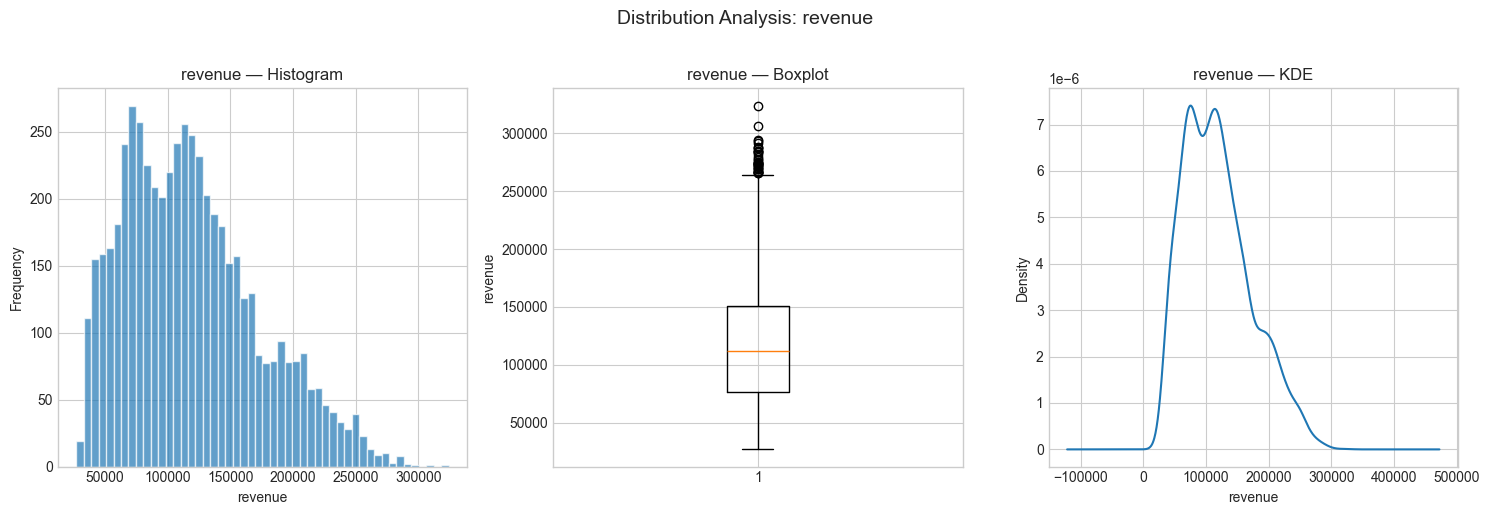

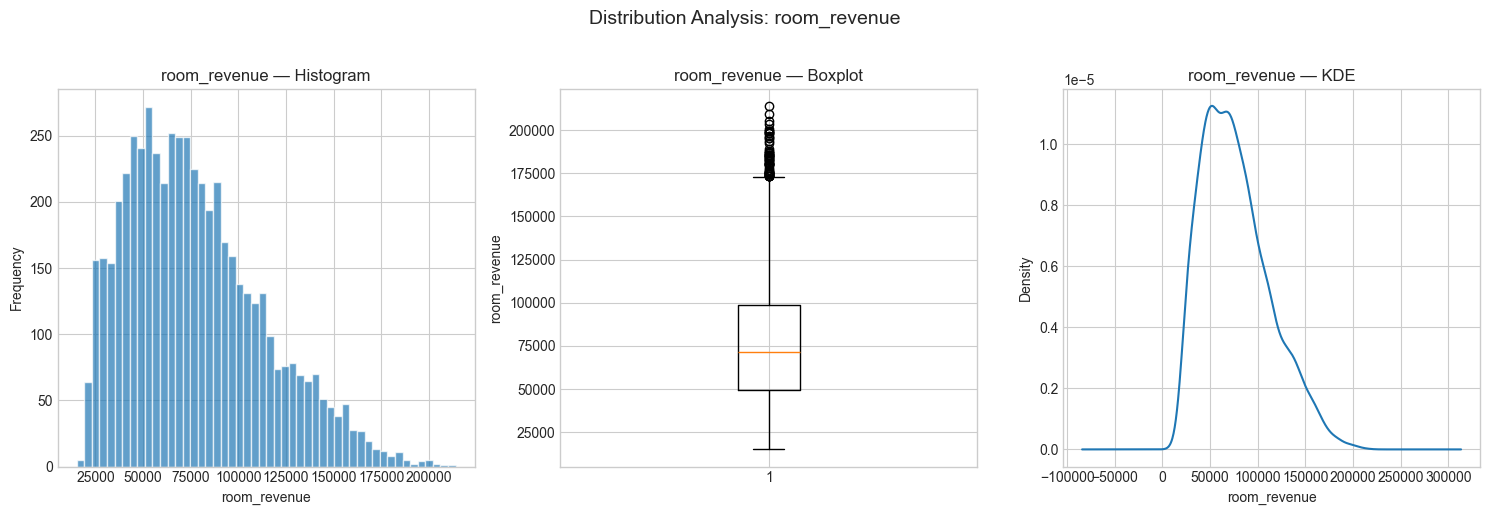

In [7]:
# Distribution plots
for col in ['revenue', 'room_revenue']:
    fig = eda_viz.plot_distributions(col)
    plt.show()

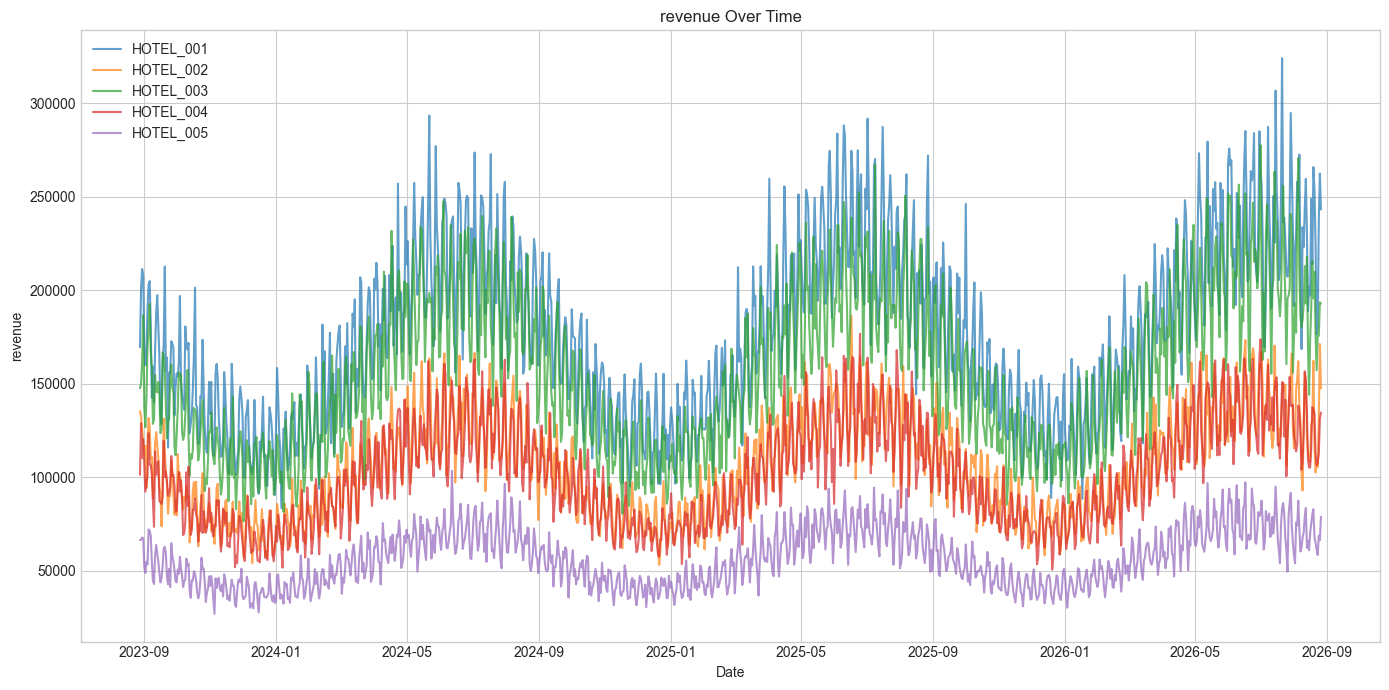

In [8]:
# Time series plot (per hotel)
fig = eda_viz.plot_time_series('revenue')
plt.show()

In [9]:
# Time series decomposition
decomp = eda.time_series_decomposition('revenue', period=7, model='additive')
fig = eda_viz.plot_decomposition(decomp, 'revenue')
plt.show()

ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
# Stationarity tests
for col in ['revenue', 'room_revenue']:
    print(f"\n=== Stationarity Tests: {col} ===")
    results = eda.stationarity_tests(col)
    for r in results:
        print(f"  {r.test_name}: stat={r.statistic:.4f}, p={r.p_value:.4f} — {r.interpretation}")

In [ ]:
# ACF/PACF
for col in ['revenue', 'room_revenue']:
    fig = eda_viz.plot_acf_pacf(col, nlags=60)
    plt.show()

In [ ]:
# Seasonality detection
for col in ['revenue', 'room_revenue']:
    print(f"\n=== Seasonality: {col} ===")
    seasonality = eda.seasonality_detection(col)
    for s in seasonality:
        print(f"  {s.pattern}: strength={s.strength:.3f}, p={s.p_value:.4f}")

In [ ]:
# Seasonal heatmap
fig = eda_viz.plot_seasonal_heatmap('revenue')
plt.show()

In [ ]:
# Outlier detection
outlier_result = eda.outlier_detection('revenue', method='iqr', threshold=1.5)
print(f"Outliers: {outlier_result.n_outliers} ({outlier_result.outlier_pct}%)")
fig = eda_viz.plot_outliers('revenue', outlier_indices=outlier_result.outlier_indices)
plt.show()

In [ ]:
# Correlation analysis
corr = eda.correlation_analysis()
fig = eda_viz.plot_correlation_heatmap(corr)
plt.show()

---
## Section 3: Preprocessing & Feature Engineering

In [ ]:
# Initialize preprocessing pipeline
pipeline = PreprocessingPipeline(
    missing_strategy=CONFIG['preprocessing']['missing_values']['strategy'],
    outlier_method=CONFIG['preprocessing']['outliers']['method'],
    outlier_action=CONFIG['preprocessing']['outliers']['action'],
    feature_config=CONFIG['preprocessing']['features'],
    split_config=CONFIG['preprocessing']['split'],
    scale_method='standard',
)

# Run full pipeline: split → fit → transform
split_result, train_df, val_df, test_df = pipeline.run(
    df, date_col='date', group_col='hotel_id'
)

print(f"Train: {len(train_df)} rows, {len(train_df.columns)} cols")
print(f"Val:   {len(val_df)} rows, {len(val_df.columns)} cols")
print(f"Test:  {len(test_df)} rows, {len(test_df.columns)} cols")
print(f"\nSplit dates: train_end={split_result.train_end.date()}, val_end={split_result.val_end.date()}")

In [ ]:
# Show engineered features
feature_cols = [c for c in train_df.columns if c not in ['date', 'hotel_id', 'revenue', 'room_revenue']]
print(f"Engineered features ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

---
## Section 4: Statistical Models

In [ ]:
# For statistical models, use a single hotel (aggregate if needed)
# We'll use the first hotel or aggregate
hotel_col = 'hotel_id'
if hotel_col in train_df.columns:
    hotels = train_df[hotel_col].unique()
    # Use first hotel for statistical models
    target_hotel = hotels[0]
    train_single = train_df[train_df[hotel_col] == target_hotel].copy()
    val_single = val_df[val_df[hotel_col] == target_hotel].copy()
    test_single = test_df[test_df[hotel_col] == target_hotel].copy()
    print(f"Using hotel: {target_hotel}")
else:
    train_single, val_single, test_single = train_df.copy(), val_df.copy(), test_df.copy()

print(f"Train: {len(train_single)}, Val: {len(val_single)}, Test: {len(test_single)}")

In [ ]:
# --- Prophet ---
print("Training Prophet...")
prophet = ProphetForecaster(
    changepoint_prior_scale=CONFIG['models']['statistical']['prophet']['changepoint_prior_scale'],
    seasonality_prior_scale=CONFIG['models']['statistical']['prophet']['seasonality_prior_scale'],
)
prophet.fit(train_single, target_col='revenue', date_col='date')
prophet_result = prophet.predict(test_single, target_col='revenue', date_col='date')
print(f"Prophet predictions: {len(prophet_result.predictions)} points")

In [ ]:
# --- SARIMAX ---
print("Training SARIMAX...")
sarimax = SARIMAXForecaster(
    seasonal_periods=CONFIG['models']['statistical']['sarimax']['seasonal_periods'],
    stepwise=CONFIG['models']['statistical']['sarimax']['stepwise'],
)
sarimax.fit(train_single, target_col='revenue', date_col='date')
sarimax_result = sarimax.predict(test_single, target_col='revenue', date_col='date')
print(f"SARIMAX predictions: {len(sarimax_result.predictions)} points")

In [ ]:
# --- ETS (Holt-Winters) ---
print("Training ETS...")
ets = ETSForecaster(
    seasonal_periods=7,
    damped_trend=True,
    auto_select=True,
)
ets.fit(train_single, target_col='revenue', date_col='date')
ets_result =ets.predict(test_single, target_col='revenue', date_col='date')
print(f"ETS predictions: {len(ets_result.predictions)} points")

In [ ]:
# Visualize statistical model forecasts
eval_viz = EvaluationVisualizer()
test_dates = pd.to_datetime(test_single['date'])

for name, result in [('Prophet', prophet_result), ('SARIMAX', sarimax_result), ('ETS', ets_result)]:
    fig = eval_viz.plot_forecast(
        result.actuals, result.predictions, dates=test_dates,
        model_name=name, lower_bound=result.lower_bound, upper_bound=result.upper_bound,
    )
    plt.show()

---
## Section 5: Machine Learning Models

In [ ]:
# Prepare feature columns for ML models
target_col = 'revenue'
drop_cols = ['date', 'hotel_id', 'revenue', 'room_revenue']
feature_cols_ml = [c for c in train_df.columns if c not in drop_cols]

print(f"ML features ({len(feature_cols_ml)}): {feature_cols_ml[:10]}...")

In [ ]:
# --- LightGBM ---
print("Training LightGBM...")
lgbm = LightGBMForecaster(
    params=CONFIG['models']['ml']['lightgbm'],
    early_stopping_rounds=50,
    categorical_features=['hotel_id'],
)
lgbm.fit(train_df, target_col=target_col, date_col='date', feature_cols=feature_cols_ml, val_df=val_df)
lgbm_result = lgbm.predict(test_df, target_col=target_col, date_col='date', feature_cols=feature_cols_ml)
print(f"LightGBM predictions: {len(lgbm_result.predictions)} points")

In [ ]:
# --- XGBoost ---
print("Training XGBoost...")
xgb = XGBoostForecaster(
    params=CONFIG['models']['ml']['xgboost'],
    early_stopping_rounds=50,
)
xgb.fit(train_df, target_col=target_col, date_col='date', feature_cols=feature_cols_ml, val_df=val_df)
xgb_result = xgb.predict(test_df, target_col=target_col, date_col='date', feature_cols=feature_cols_ml)
print(f"XGBoost predictions: {len(xgb_result.predictions)} points")

In [ ]:
# --- CatBoost ---
print("Training CatBoost...")
cat = CatBoostForecaster(
    params=CONFIG['models']['ml']['catboost'],
    early_stopping_rounds=50,
    cat_features=['hotel_id'],
)
cat.fit(train_df, target_col=target_col, date_col='date', feature_cols=feature_cols_ml, val_df=val_df)
cat_result = cat.predict(test_df, target_col=target_col, date_col='date', feature_cols=feature_cols_ml)
print(f"CatBoost predictions: {len(cat_result.predictions)} points")

In [ ]:
# Visualize ML model forecasts
for name, result in [('LightGBM', lgbm_result), ('XGBoost', xgb_result), ('CatBoost', cat_result)]:
    fig = eval_viz.plot_forecast(
        result.actuals, result.predictions, dates=test_dates,
        model_name=name,
    )
    plt.show()

---
## Section 6: Deep Learning Models

In [ ]:
# --- TimesFM (Foundation Model) ---
print("Initializing TimesFM...")
timesfm = TimesFMForecaster(
    checkpoint=CONFIG['models']['dl']['timesfm']['checkpoint'],
    context_len=CONFIG['models']['dl']['timesfm']['context_len'],
    horizon=CONFIG['models']['dl']['timesfm']['horizon'],
)
timesfm.fit(train_single, target_col='revenue', date_col='date')
timesfm_result = timesfm.predict(test_single, target_col='revenue', date_col='date')
print(f"TimesFM predictions: {len(timesfm_result.predictions)} points")

In [ ]:
# --- PatchTST ---
print("Training PatchTST...")
patchtst = PatchTSTForecaster(
    patch_len=CONFIG['models']['dl']['patchtst']['patch_len'],
    stride=CONFIG['models']['dl']['patchtst']['stride'],
    d_model=CONFIG['models']['dl']['patchtst']['d_model'],
    n_heads=CONFIG['models']['dl']['patchtst']['n_heads'],
    n_layers=CONFIG['models']['dl']['patchtst']['n_layers'],
    epochs=CONFIG['models']['dl']['patchtst']['epochs'],
    batch_size=CONFIG['models']['dl']['patchtst']['batch_size'],
    patience=CONFIG['models']['dl']['patchtst']['patience'],
)
patchtst.fit(train_single, target_col='revenue', date_col='date', val_df=val_single)
patchtst_result = patchtst.predict(test_single, target_col='revenue', date_col='date')
print(f"PatchTST predictions: {len(patchtst_result.predictions)} points")

In [ ]:
# Visualize DL model forecasts
for name, result in [('TimesFM', timesfm_result), ('PatchTST', patchtst_result)]:
    fig = eval_viz.plot_forecast(
        result.actuals, result.predictions, dates=test_dates,
        model_name=name, lower_bound=result.lower_bound, upper_bound=result.upper_bound,
    )
    plt.show()

---
## Section 7: Final Comparison & Evaluation

In [ ]:
# Evaluate all models
evaluator = Evaluator()

# Collect all results
all_results = {
    'Prophet': (prophet_result.actuals, prophet_result.predictions),
    'SARIMAX': (sarimax_result.actuals, sarimax_result.predictions),
    'ETS': (ets_result.actuals, ets_result.predictions),
    'LightGBM': (lgbm_result.actuals, lgbm_result.predictions),
    'XGBoost': (xgb_result.actuals, xgb_result.predictions),
    'CatBoost': (cat_result.actuals, cat_result.predictions),
    'TimesFM': (timesfm_result.actuals, timesfm_result.predictions),
    'PatchTST': (patchtst_result.actuals, patchtst_result.predictions),
}

# Compute metrics
metrics_results = evaluator.compute_all_metrics(all_results, split='test')

# Build comparison table
comparison_df = evaluator.comparison_table(metrics_results)
print("=== Model Comparison (Test Set) ===")
comparison_df

In [ ]:
# Comparison visualization
fig = eval_viz.plot_comparison_table(comparison_df)
plt.show()

In [ ]:
# Rank models by primary metric
comparison = evaluator.compare_models(metrics_results, primary_metric='MAE')
print(f"\nBest model (by MAE): {comparison.best_model}")
print(f"\nRankings by MAE: {comparison.rankings.get('MAE', [])}")

In [ ]:
# Diebold-Mariano test: best model vs second best
if len(metrics_results) >= 2:
    ranked = comparison.rankings.get('MAE', [])
    if len(ranked) >= 2:
        model_a, model_b = ranked[0], ranked[1]
        actuals_a, preds_a = all_results[model_a]
        _, preds_b = all_results[model_b]
        dm = evaluator.diebold_mariano_test(actuals_a, preds_a, preds_b)
        print(f"\nDiebold-Mariano Test: {model_a} vs {model_b}")
        print(f"  DM statistic: {dm['dm_statistic']}")
        print(f"  p-value: {dm['p_value']}")
        print(f"  Significant: {dm['significant']}")

In [ ]:
# Residual diagnostics for best model
best_name = comparison.best_model
actuals_best, preds_best = all_results[best_name]
diag = evaluator.residual_diagnostics(actuals_best, preds_best)
print(f"\nResidual Diagnostics — {best_name}:")
for test_name, result in diag.items():
    print(f"  {test_name}: {result}")

In [ ]:
# Scatter and error distribution for best model
fig = eval_viz.plot_scatter(actuals_best, preds_best, model_name=best_name)
plt.show()

fig = eval_viz.plot_error_distribution(actuals_best, preds_best, model_name=best_name)
plt.show()

fig = eval_viz.plot_qq(actuals_best, preds_best, model_name=best_name)
plt.show()

---
## Section 8: Future Forecast

In [ ]:
# Select best model for future forecasting
model_map = {
    'Prophet': prophet, 'SARIMAX': sarimax, 'ETS': ets,
    'LightGBM': lgbm, 'XGBoost': xgb, 'CatBoost': cat,
    'TimesFM': timesfm, 'PatchTST': patchtst,
}
best_model = model_map[best_name]

# Generate future forecast
horizon = CONFIG['forecasting']['horizon_days']
forecaster = FutureForecaster(best_model, horizon_days=horizon)

report = forecaster.generate_forecast(
    train_df, target_col='revenue', date_col='date', hotel_col='hotel_id',
    feature_cols=feature_cols_ml if hasattr(best_model, '_feature_names') else None,
)

print(f"\n=== Forecast Summary ===")
for key, value in report.summary.items():
    print(f"  {key}: {value}")

In [ ]:
# Plot future forecast
fig, ax = plt.subplots(figsize=(14, 7))

forecast_df = report.forecasts
if 'hotel_id' in forecast_df.columns:
    # Plot aggregated forecast
    agg = forecast_df[forecast_df['hotel_id'] == 'AGGREGATED']
    ax.plot(pd.to_datetime(agg['date']), agg['revenue'],
            label='Forecast (Aggregated)', color='coral', linewidth=2)
    
    # Plot individual hotel forecasts
    for hotel in forecast_df[forecast_df['hotel_id'] != 'AGGREGATED']['hotel_id'].unique():
        hotel_data = forecast_df[forecast_df['hotel_id'] == hotel]
        ax.plot(pd.to_datetime(hotel_data['date']), hotel_data['revenue'],
                alpha=0.3, linestyle='--')
else:
    ax.plot(pd.to_datetime(forecast_df['date']), forecast_df['revenue'],
            label='Forecast', color='coral', linewidth=2)

# Add historical data
hist = train_df.groupby('date')['revenue'].sum().reset_index()
ax.plot(pd.to_datetime(hist['date']), hist['revenue'],
        label='Historical', color='steelblue', linewidth=1.5)

ax.axvline(x=split_result.val_end, color='gray', linestyle='--', alpha=0.5, label='Forecast Start')
ax.set_title(f'Hotel Revenue Forecast — {horizon} Days Ahead ({best_name})')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue')
ax.legend()
fig.tight_layout()
plt.show()

In [ ]:
# Assumptions & Limitations
print("=== Assumptions ===")
for i, a in enumerate(report.assumptions, 1):
    print(f"  {i}. {a}")

print("\n=== Limitations ===")
for i, l in enumerate(report.limitations, 1):
    print(f"  {i}. {l}")

print("\n=== Recommendations ===")
for i, r in enumerate(report.recommendations, 1):
    print(f"  {i}. {r}")

---
## Section 9: Conclusions

In [ ]:
print("=" * 60)
print("           CONCLUSIONES Y RECOMENDACIONES")
print("=" * 60)
print(f"\n1. MODELO SELECCIONADO: {best_name}")
print(f"   - MAE: {comparison_df.loc[best_name, 'MAE']:.2f}")
print(f"   - RMSE: {comparison_df.loc[best_name, 'RMSE']:.2f}")
print(f"   - MAPE: {comparison_df.loc[best_name, 'MAPE']:.2f}%")
print(f"\n2. HORIZONTE DE PRONÓSTICO: {horizon} días")
print(f"   - Total pronosticado: ${report.summary.get('total_forecasted', 0):,.2f}")
print(f"   - Media diaria: ${report.summary.get('daily_mean', 0):,.2f}")
print(f"\n3. PRÓXIMOS PASOS:")
print("   - Incorporar datos exógenos (clima, eventos)")
print("   - Implementar ensamble de modelos top-3")
print("   - Establecer reentrenamiento automático")
print("   - Validar con expertos del dominio")
print("\n4. REPRODUCIBILIDAD:")
print(f"   - Semilla: {SEED}")
print(f"   - Config: config.yaml")
print(f"   - Dependencies: requirements.txt")
print("=" * 60)